Succes! Graficul a fost salvat în: images/tema_d_corelatie_iris.png


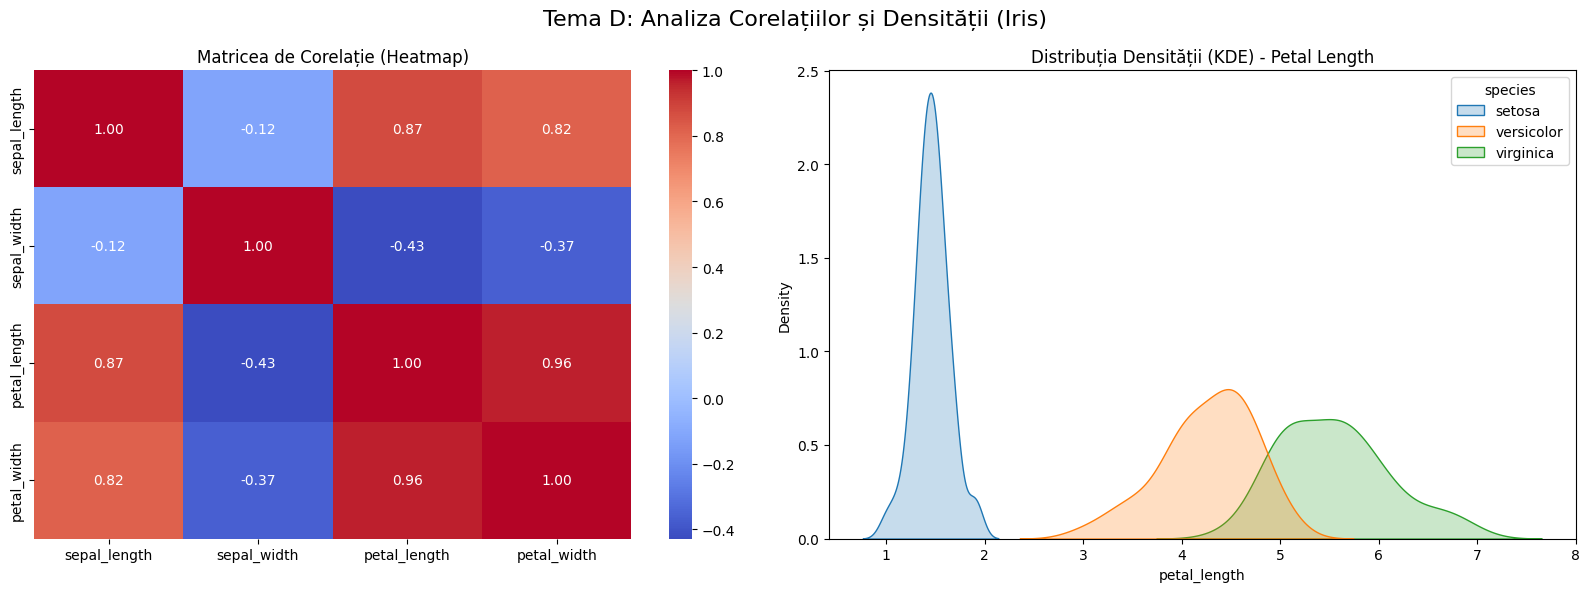


Cea mai puternică corelație între variabile diferite:
petal_length  petal_width    0.962865
dtype: float64


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Pregătirea mediului și a datelor
output_dir = "images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Încărcăm dataset-ul 'iris' (standard pentru analiza corelațiilor)
iris = sns.load_dataset('iris')

# Pentru corelație, avem nevoie doar de coloanele numerice
# Excludem coloana 'species' care este de tip obiect/categorie
numeric_iris = iris.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_iris.corr()

# 2. Crearea vizualizării
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tema D: Analiza Corelațiilor și Densității (Iris)', fontsize=16)

# Grafic 1: Heatmap pentru Matricea de Corelație
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Matricea de Corelație (Heatmap)')

# Grafic 2: KDE Plot (Kernel Density Estimate) pentru distribuția lungimii petalelor
sns.kdeplot(data=iris, x='petal_length', hue='species', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Distribuția Densității (KDE) - Petal Length')

# 3. Salvarea și afișarea
save_path = os.path.join(output_dir, 'tema_d_corelatie_iris.png')
plt.tight_layout()
plt.savefig(save_path, dpi=150)
print(f"Succes! Graficul a fost salvat în: {save_path}")
plt.show()

# 4. Scurtă concluzie în consolă
strongest_corr = corr_matrix.unstack().sort_values(ascending=False)
# Eliminăm corelațiile de 1.0 (auto-corelație)
print("\nCea mai puternică corelație între variabile diferite:")
print(strongest_corr[strongest_corr < 1].head(1))